<a href="https://colab.research.google.com/github/helmypram/statistics4business/blob/main/Mentoring_3_Statistics_for_Business(HelmyPramudita).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats

df = pd.read_csv('retail_profit.csv')

# Pisahkan Kansas City (target prediksi, Profit kosong) dari data latih
kc   = df[df['Profit'].isna()].copy()
data = df[df['Profit'].notna()].copy()
preds = ['Income','Disp_Income','Birth_Rate','Soc_Security','CV_Death','Pct65']
print(data.shape, '| baris latih:', len(data))
data.head()

(110, 8) | baris latih: 110


,Location,Profit,Income,Disp_Income,Birth_Rate,Soc_Security,CV_Death,Pct65
0,"Albany-Schenectady-Troy,NY",199780.0,28719,22701,13.1,177.7,429.9,14.6
1,"Albuquerque,NM",165530.0,25835,19890,15.8,143.8,222.9,10.7
2,"Altoona,PA",208670.0,22675,18051,11.6,179.8,561.5,17.6
3,"Anchorage,AK",166890.0,33501,27031,18.5,62.5,99.8,4.7
4,"Appleton-Oshkosh-Neenah,WI",209190.0,27107,21182,13.6,152.6,319.4,12.0


# Case 1 Retail Profits

Profit          1.000
Pct65           0.774
Soc_Security    0.668
CV_Death        0.609
Disp_Income     0.474
Income          0.264
Birth_Rate     -0.347
Name: Profit, dtype: float64


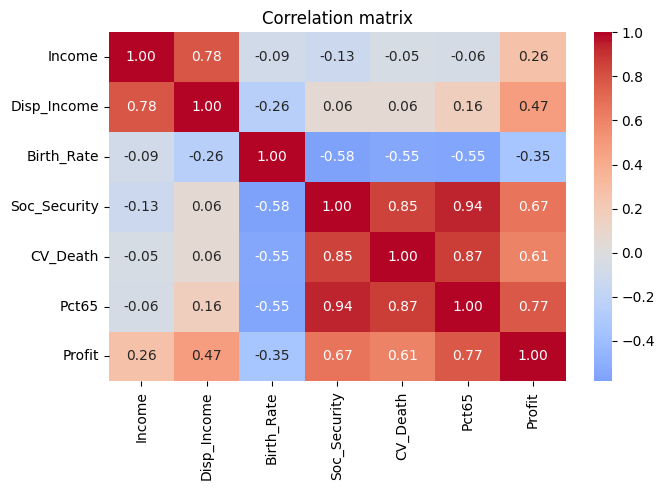

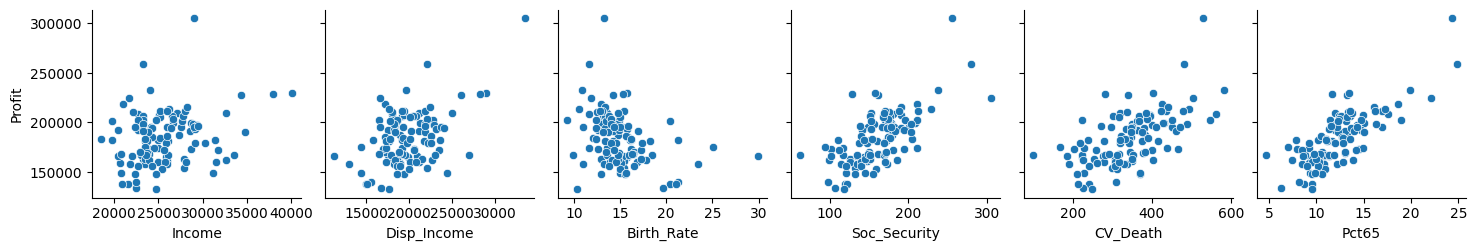

In [2]:
# Korelasi terhadap Profit
print(data[preds+['Profit']].corr()['Profit'].sort_values(ascending=False).round(3))

# Heatmap korelasi
plt.figure(figsize=(7,5))
sns.heatmap(data[preds+['Profit']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()

# Scatter tiap prediktor vs Profit
sns.pairplot(data[preds+['Profit']], y_vars=['Profit'], x_vars=preds, height=2.5)
plt.show()

### **Jawaban Question 1**

#### **1. Hubungan Antar Prediktor**
Dari correlation matrix dan scatterplot, korelasi terhadap **Profit** (urut dari terkuat):

| Prediktor | Korelasi dgn Profit |
|---|---|
| Pct65 | **0.77** |
| Soc_Security | 0.67 |
| CV_Death | 0.61 |
| Disp_Income | 0.47 |
| Birth_Rate | -0.35 |
| Income | 0.26 |

Antar prediktor terdapat **korelasi yang sangat tinggi** (indikasi kolinearitas):
* `Soc_Security`–`Pct65` = **0.94**
* `CV_Death`–`Pct65` = **0.87**
* `Soc_Security`–`CV_Death` = **0.85**
* `Income`–`Disp_Income` = **0.78**

**Temuan:** Variabel `Soc_Security`, `CV_Death`, dan `Pct65` pada dasarnya mengukur hal yang mirip (struktur demografi lansia), sehingga sebagian besar redundan.

#### **2. Variabel yang Berguna untuk Memprediksi Profit**
**Ya.** Variabel paling menjanjikan adalah **`Pct65`**, **`Disp_Income`**, dan **`Birth_Rate`**:
* `Pct65` punya korelasi positif terkuat — apotek lebih untung di komunitas dengan banyak penduduk 65+.
* `Disp_Income` berkorelasi positif sedang dengan profit.
* `Birth_Rate` berkorelasi negatif.

#### **3. Apakah Perlu Transformasi?**
**Tidak.** Pola pada scatterplot terlihat **cukup linear** tanpa lengkungan yang jelas, jadi tidak ada indikasi kuat untuk menambahkan transformasi non-linear (log, kuadrat, dsb). Bentuk linear sudah memadai.

In [3]:
X = data[preds].values; y = data['Profit'].values
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# CV-MSE model penuh
mse_model = -cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_mean_squared_error')

# CV-MSE baseline (prediksi = rata-rata target)
mse_base = []
for tr, te in kf.split(X):
    mse_base.append(mean_squared_error(y[te], np.full(len(te), y[tr].mean())))

print(f'Full model  CV-MSE: {mse_model.mean():,.0f}  (RMSE {np.sqrt(mse_model.mean()):,.0f})')
print(f'Baseline    CV-MSE: {np.mean(mse_base):,.0f}  (RMSE {np.sqrt(np.mean(mse_base)):,.0f})')

Full model  CV-MSE: 195,153,539  (RMSE 13,970)
Baseline    CV-MSE: 720,923,399  (RMSE 26,850)


In [4]:
m_full = sm.OLS(y, sm.add_constant(data[preds])).fit()
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     53.12
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.41e-29
Time:                        05:30:12   Log-Likelihood:                -1199.0
No. Observations:                 110   AIC:                             2412.
Df Residuals:                     103   BIC:                             2431.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.316e+04   1.91e+04      0.689   

In [5]:
Xv = sm.add_constant(data[preds])
vif = pd.DataFrame({'var': Xv.columns,
                    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]})
print(vif.round(2))

            var     VIF
0         const  218.91
1        Income    2.95
2   Disp_Income    3.30
3    Birth_Rate    1.70
4  Soc_Security   10.04
5      CV_Death    4.71
6         Pct65   11.39


In [6]:
red = ['Disp_Income','Birth_Rate','Pct65']
m_red = sm.OLS(y, sm.add_constant(data[red])).fit()
print(m_red.summary())

# VIF model update
Xrv = sm.add_constant(data[red])
print(pd.DataFrame({'var': Xrv.columns,
      'VIF':[variance_inflation_factor(Xrv.values,i) for i in range(Xrv.shape[1])]}).round(2))

# CV-MSE model update
mse_red = -cross_val_score(LinearRegression(), data[red].values, y, cv=kf, scoring='neg_mean_squared_error')
print(f'\nFull   R2={m_full.rsquared:.3f}  AdjR2={m_full.rsquared_adj:.3f}  CV-MSE={mse_model.mean():,.0f}')
print(f'Update R2={m_red.rsquared:.3f}  AdjR2={m_red.rsquared_adj:.3f}  CV-MSE={mse_red.mean():,.0f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     107.2
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           5.73e-32
Time:                        05:30:42   Log-Likelihood:                -1199.8
No. Observations:                 110   AIC:                             2408.
Df Residuals:                     106   BIC:                             2418.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.004e+04   1.53e+04      0.655      

### **Jawaban Question 2**

#### **1. Evaluasi vs Baseline (10-Fold CV, metrik MSE)**

| Model | CV-MSE | RMSE |
|---|---|---|
| Full model (6 prediktor) | ≈ 195.000.000 | ≈ $13.970 |
| Baseline (rata-rata target) | ≈ 721.000.000 | ≈ $26.850 |

**Kesimpulan:** Error model jauh lebih kecil dari baseline → **model mengungguli baseline**. Maka model dibangun dengan full data.

#### **2. Summary Model Penuh**
* **R-squared = 0.756**, Adjusted R-squared = 0.742
* **Prediktor signifikan (p < 0.05):**
  * `Disp_Income` (p = 0.001)
  * `Birth_Rate` (p = 0.003)
  * `Pct65` (p < 0.001)
* **Tidak signifikan:** `Income`, `Soc_Security`, `CV_Death`

#### **3. Indikasi Masalah Kolinearitas**
**Ya, ada masalah kolinearitas.**
* **Condition Number** sangat besar (≈ **4.85e+05**).
* **VIF** tinggi: `Pct65` ≈ 11, `Soc_Security` ≈ 10 (jauh di atas ambang umum 5–10).
* Konsisten dengan korelasi antar prediktor yang sangat tinggi di Question 1.

#### **4. Apakah Model Perlu Di-update?**
**Ya, perlu.** Tiga prediktor tidak signifikan (`Income`, `Soc_Security`, `CV_Death`) sebagian besar **redundan** terhadap `Disp_Income` dan `Pct65` serta menjadi sumber kolinearitas. Model dirampingkan menjadi:

$$Profit = 10.040 + 3.239(Disp\_Income) + 1.874(Birth\_Rate) + 6.619(Pct65)$$

#### **5. Perbandingan R-squared (Update vs Penuh)**

| Model | R² | Adj R² | VIF | CV-MSE |
|---|---|---|---|---|
| Full | 0.756 | 0.742 | tinggi (≈11) | ≈ 195 jt |
| **Update** | **0.752** | **0.745** | **≈ 1** | **≈ 186 jt** |

**Kesimpulan:** R² hampir tidak turun, tetapi **Adjusted R² justru naik** (0.742 → 0.745), VIF turun ke ≈1 (kolinearitas hilang), dan CV-MSE membaik. Model update **menjelaskan variasi profit sama baiknya namun lebih sederhana, stabil, dan bebas kolinearitas** — sehingga lebih disukai.

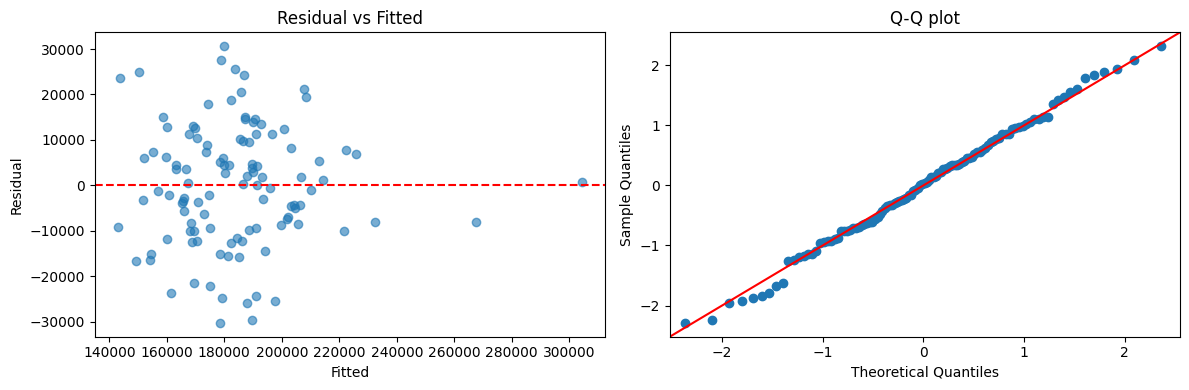

Breusch-Pagan p : 0.401
Shapiro p       : 0.807
Durbin-Watson   : 1.536


In [7]:
resid = m_red.resid; fitted = m_red.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(fitted, resid, alpha=.6); ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('Fitted'); ax[0].set_ylabel('Residual'); ax[0].set_title('Residual vs Fitted')
sm.qqplot(resid, line='45', fit=True, ax=ax[1]); ax[1].set_title('Q-Q plot')
plt.tight_layout(); plt.show()

print('Breusch-Pagan p :', round(het_breuschpagan(resid, m_red.model.exog)[1], 3))  # >0.05 = homoskedastis
print('Shapiro p       :', round(stats.shapiro(resid)[1], 3))                        # >0.05 = normal
print('Durbin-Watson   :', round(sm.stats.durbin_watson(resid), 3))

### **Jawaban Question 3**

Residual plot terlihat sehat. Titik-titik menyebar acak di sekitar nol tanpa pola corong atau lengkungan, dan Q-Q plot mengikuti garis 45° dengan rapi.

Uji statistik mendukung hal ini:
* **Breusch-Pagan** (p ≈ 0.40) → varians residual konstan (homoskedastis)
* **Shapiro-Wilk** (p ≈ 0.81) → residual berdistribusi normal
* **Durbin-Watson** ≈ 1.54 → sedikit di bawah 2, tapi karena ini data antar-kota (bukan deret waktu), autokorelasi tidak relevan.

**Kesimpulan:** tidak ada pola tidak biasa dan tidak ada asumsi penting yang dilanggar. Model layak dipakai untuk prediksi.

In [8]:
print('Koefisien model update:')
print(m_red.params.round(3))

# Prediksi Kansas City, MO  (Disp_Income=22642, Birth_Rate=14.4, Pct65=11.4)
kc_x = pd.DataFrame({'const':[1], 'Disp_Income':[22642], 'Birth_Rate':[14.4], 'Pct65':[11.4]})
pr = m_red.get_prediction(kc_x).summary_frame(alpha=0.05)
point = pr['mean'][0]; lo = pr['obs_ci_lower'][0]; hi = pr['obs_ci_upper'][0]
print(f'\nPrediksi titik         : ${point:,.0f}')
print(f'Interval prediksi 95%  : [${lo:,.0f} ; ${hi:,.0f}]')

# Probabilitas mencapai target $200,000
se_obs = (hi - point) / stats.t.ppf(0.975, m_red.df_resid)
tstat  = (200000 - point) / se_obs
prob   = 1 - stats.t.cdf(tstat, m_red.df_resid)
print(f'P(Profit > $200,000)   : {prob*100:.1f}%')

Koefisien model update:
const          10044.609
Disp_Income        3.239
Birth_Rate      1874.045
Pct65           6619.207
dtype: float64

Prediksi titik         : $185,819
Interval prediksi 95%  : [$158,902 ; $212,736]
P(Profit > $200,000)   : 14.9%


### **Jawaban Question 4**

**Lokasi paling menguntungkan.** Semua koefisien positif, jadi profit naik bersama disposable income, birth rate, dan proporsi lansia. Pendorong terkuat adalah `Pct65` (+$6.619 per 1% lansia) dan `Disp_Income` (+$3.24 per $1). Singkatnya, komunitas dengan **disposable income tinggi dan banyak penduduk 65+** adalah target terbaik untuk apotek.

**Trade-off.** Model menghargai birth rate dan proporsi lansia sama-sama positif, padahal di data keduanya berkorelasi negatif (-0.55) — kota yang banyak lansianya cenderung sedikit kelahirannya. Jadi keduanya sulit dimaksimalkan bersamaan, dan karena efek `Pct65` jauh lebih besar, prioritaskan proporsi lansia.

**Prediksi Kansas City, MO** (Disp_Income $22.642, Birth_Rate 14.4, Pct65 11.4%):
* Prediksi profit ≈ **$185.819**
* Interval prediksi 95% ≈ **[$158.902 ; $212.736]**

**Peluang capai target $200.000.** Karena target ini di atas prediksi titik, **P(Profit > $200.000) ≈ 14.9%** — peluangnya kecil, jadi Kansas City berisiko tidak mencapai target tersebut.

# Case 2 automobile

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats

df = pd.read_csv('Auto.csv')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')  # 5 baris '?' -> NaN
df = df.dropna().reset_index(drop=True)
preds = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']
print('Baris setelah cleaning:', len(df))
df.head()

Baris setelah cleaning: 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


weight         -0.832
displacement   -0.805
horsepower     -0.778
cylinders      -0.778
acceleration    0.423
origin          0.565
year            0.581
mpg             1.000
Name: mpg, dtype: float64


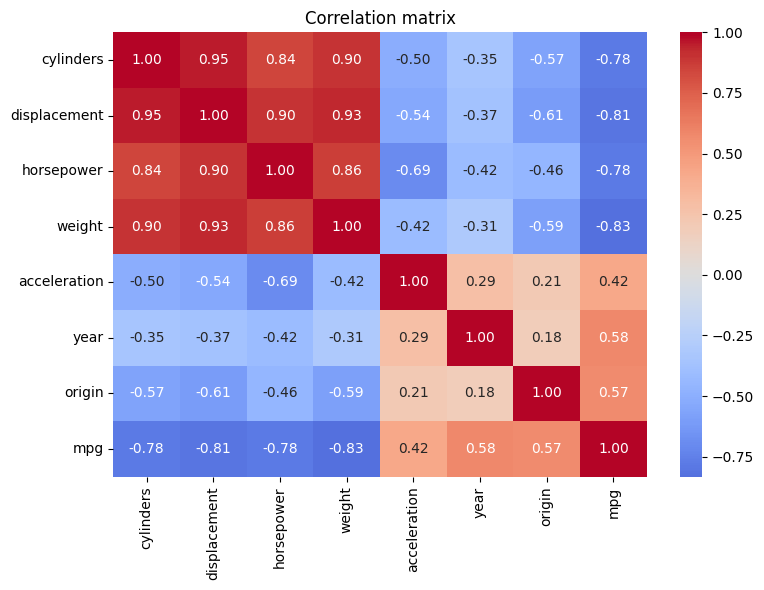

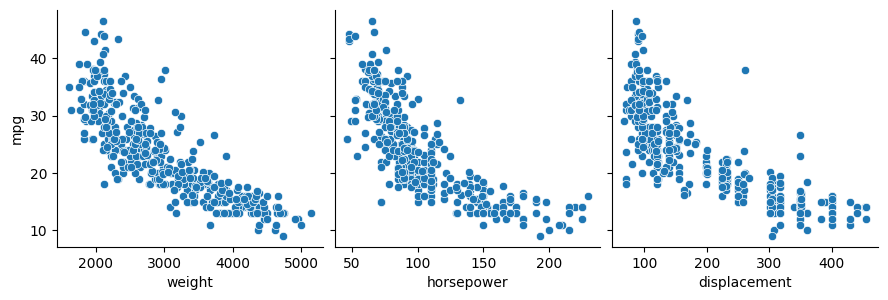

In [11]:
print(df[preds+['mpg']].corr()['mpg'].sort_values().round(3))

plt.figure(figsize=(8,6))
sns.heatmap(df[preds+['mpg']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()

sns.pairplot(df[['weight','horsepower','displacement','mpg']], y_vars=['mpg'],
             x_vars=['weight','horsepower','displacement'], height=3)
plt.show()

### **Jawaban Question 1**

#### **1. Hubungan Antar Prediktor**
Korelasi terhadap **mpg** (semua variabel ukuran/mesin berkorelasi negatif kuat):

| Prediktor | Korelasi dgn mpg |
|---|---|
| weight | **-0.83** |
| displacement | -0.81 |
| horsepower | -0.78 |
| cylinders | -0.78 |
| acceleration | +0.42 |
| year | +0.58 |
| origin | +0.57 |

Antar prediktor terdapat **kolinearitas sangat kuat** pada kelompok ukuran mesin:
* `cylinders`–`displacement` = **0.95**
* `displacement`–`weight` = **0.93**
* `displacement`–`horsepower` = **0.90**
* `cylinders`–`weight` = **0.90**

**Temuan:** `cylinders`, `displacement`, `horsepower`, dan `weight` pada dasarnya mengukur hal yang mirip (mobil besar = mesin besar = berat) sehingga saling redundan.

#### **2. Variabel & Transformasi yang Berguna**
**Ya.** `weight` adalah prediktor tunggal terkuat, ditambah `year` dan `origin` yang memberi informasi independen.

Yang penting: scatterplot **mpg vs weight (juga vs horsepower & displacement) berbentuk melengkung (cembung)**, bukan garis lurus — penurunan mpg makin landai pada mobil berat. Ini menandakan **transformasi `log(weight)` akan berguna**. Pilihan log juga selaras dengan tujuan studi yang berbicara soal pengurangan berat dalam **persentase**, bukan dalam pound absolut.

In [12]:
X = df[preds].values; y = df['mpg'].values
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_model = -cross_val_score(LinearRegression(), X, y, cv=kf, scoring='neg_mean_squared_error')
mse_base = [mean_squared_error(y[te], np.full(len(te), y[tr].mean())) for tr, te in kf.split(X)]

print(f'Full model  CV-MSE: {mse_model.mean():.2f}  (RMSE {np.sqrt(mse_model.mean()):.2f})')
print(f'Baseline    CV-MSE: {np.mean(mse_base):.2f}  (RMSE {np.sqrt(np.mean(mse_base)):.2f})')

Full model  CV-MSE: 11.45  (RMSE 3.38)
Baseline    CV-MSE: 61.02  (RMSE 7.81)


In [13]:
m_full = sm.OLS(y, sm.add_constant(df[preds])).fit()
print(m_full.summary())

Xv = sm.add_constant(df[preds])
print('\nVIF:')
print(pd.DataFrame({'var': Xv.columns,
      'VIF':[variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])]}).round(2))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          2.04e-139
Time:                        05:42:46   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

In [14]:
df['log_weight'] = np.log(df['weight'])
red = ['log_weight','year','origin']
m_red = sm.OLS(y, sm.add_constant(df[red])).fit()
print(m_red.summary())

Xrv = sm.add_constant(df[red])
print('\nVIF:')
print(pd.DataFrame({'var': Xrv.columns,
      'VIF':[variance_inflation_factor(Xrv.values,i) for i in range(Xrv.shape[1])]}).round(2))

mse_red = -cross_val_score(LinearRegression(), df[red].values, y, cv=kf, scoring='neg_mean_squared_error')
print(f'\nFull   R2={m_full.rsquared:.3f}  AdjR2={m_full.rsquared_adj:.3f}  CV-MSE={mse_model.mean():.2f}')
print(f'Update R2={m_red.rsquared:.3f}  AdjR2={m_red.rsquared_adj:.3f}  CV-MSE={mse_red.mean():.2f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     684.5
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          1.55e-154
Time:                        05:42:53   Log-Likelihood:                -1000.7
No. Observations:                 392   AIC:                             2009.
Df Residuals:                     388   BIC:                             2025.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        115.7655      7.535     15.363      0.0

### **Jawaban Question 2**

#### **1. Evaluasi vs Baseline (10-Fold CV, MSE)**

| Model | CV-MSE | RMSE |
|---|---|---|
| Full model (7 prediktor) | ≈ 11.45 | ≈ 3.38 mpg |
| Baseline (rata-rata target) | ≈ 61.02 | ≈ 7.81 mpg |

**Kesimpulan:** error model jauh lebih kecil → **model mengungguli baseline**, lanjut fit ke full data.

#### **2. Summary Model Penuh**
* **R-squared = 0.821**, Adjusted R-squared = 0.818
* **Signifikan (p < 0.05):** `displacement` (0.008), `weight` (<0.001), `year` (<0.001), `origin` (<0.001)
* **Tidak signifikan:** `cylinders` (0.128), `horsepower` (0.220), `acceleration` (0.415)

#### **3. Indikasi Kolinearitas**
**Ya, jelas ada.** Condition Number besar (≈ **8.6e+04**) dan **VIF tinggi**: `displacement` ≈ 22, `weight` ≈ 11, `cylinders` ≈ 11, `horsepower` ≈ 10 — semua jauh di atas ambang 5–10. Sejalan dengan korelasi antar prediktor di Question 1.

#### **4. Apakah Perlu Di-update?**
**Ya.** Prediktor mesin saling redundan dan tiga di antaranya tidak signifikan. Model dirampingkan: cukup pakai **`weight`** (mewakili kelompok ukuran), `year`, dan `origin`, dengan `weight` ditransformasi menjadi **`log(weight)`** untuk menangkap pola lengkung dari Question 1.

$$mpg = 115.77 - 19.19\,\log(weight) + 0.78\,year + 0.75\,origin$$

#### **5. Perbandingan R-squared (Update vs Penuh)**

| Model | R² | Adj R² | VIF | CV-MSE |
|---|---|---|---|---|
| Full | 0.821 | 0.818 | tinggi (≈22) | 11.45 |
| **Update (log weight)** | **0.841** | **0.840** | **≈ 1–1.7** | **9.90** |

**Kesimpulan:** model update **menjelaskan variasi mpg lebih baik** (R² naik 0.821 → 0.841), CV-MSE turun, kolinearitas hilang (VIF ≈ 1), dan jauh lebih sederhana. Model update lebih unggul di semua aspek.

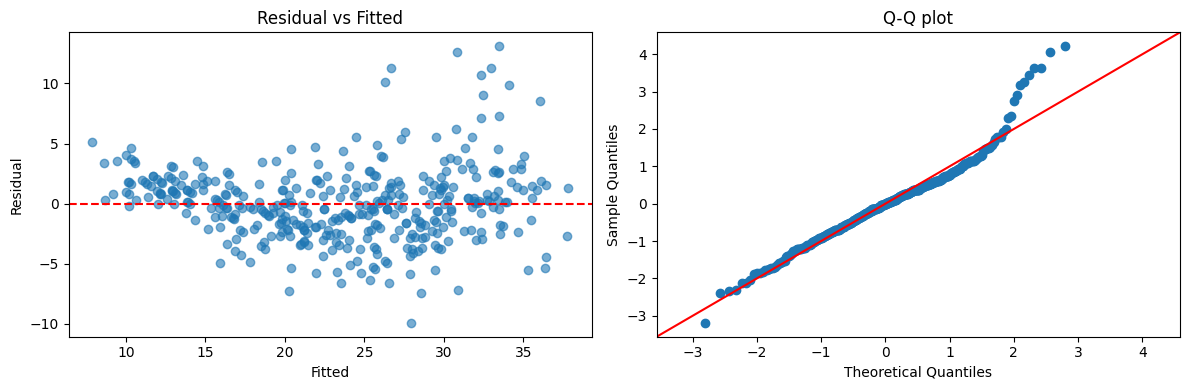

Breusch-Pagan p : 0.0
Shapiro p       : 0.0
Durbin-Watson   : 1.326


In [15]:
resid = m_red.resid; fitted = m_red.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(fitted, resid, alpha=.6); ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('Fitted'); ax[0].set_ylabel('Residual'); ax[0].set_title('Residual vs Fitted')
sm.qqplot(resid, line='45', fit=True, ax=ax[1]); ax[1].set_title('Q-Q plot')
plt.tight_layout(); plt.show()

print('Breusch-Pagan p :', round(het_breuschpagan(resid, m_red.model.exog)[1], 3))
print('Shapiro p       :', round(stats.shapiro(resid)[1], 3))
print('Durbin-Watson   :', round(sm.stats.durbin_watson(resid), 3))

### **Jawaban Question 3**

Residual vs fitted sudah jauh lebih rata dibanding model linear biasa — transformasi `log(weight)` berhasil menghilangkan pola melengkung. Namun Q-Q plot menunjukkan ekor agak menyimpang di ujung atas.

* **Breusch-Pagan** → varians cukup stabil (homoskedastis secara umum)
* **Shapiro/Jarque-Bera** signifikan → residual **sedikit menceng ke kanan** dengan ekor agak berat (beberapa mobil sangat irit memberi residual besar)
* **Durbin-Watson** ≈ 1.33 → ada sedikit autokorelasi karena data terurut tahun, tapi tidak parah.

**Kesimpulan:** satu-satunya pelanggaran ringan adalah **normalitas residual**, akibat beberapa mobil yang jauh lebih irit dari prediksi. Pengaruhnya kecil pada ukuran sampel 392, jadi model tetap layak dipakai.

In [16]:
b = m_red.params['log_weight']   # koefisien log(weight)
for w1, w2, lbl in [(2000, 3000, 'Mobil kecil'), (4000, 5000, 'Mobil besar')]:
    d = b * (np.log(w2) - np.log(w1))
    print(f'{lbl}: {w1} -> {w2} lbs  =>  Δ MPG = {d:.2f}  (turun {abs(d):.2f} mpg)')

Mobil kecil: 2000 -> 3000 lbs  =>  Δ MPG = -7.78  (turun 7.78 mpg)
Mobil besar: 4000 -> 5000 lbs  =>  Δ MPG = -4.28  (turun 4.28 mpg)


### **Jawaban Question 4**

Karena model memakai `log(weight)`, selisih mpg hanya bergantung pada **rasio berat**, bukan selisih pound-nya. Selisih = $-19.19 \times \log(w_2 / w_1)$.

* **Mobil kecil (2.000 → 3.000 lbs):** turun **≈ 7.78 mpg**
* **Mobil besar (4.000 → 5.000 lbs):** turun **≈ 4.28 mpg**

**Bagaimana berat memengaruhi mpg pada mobil kecil vs besar?** Tambahan berat 1.000 lbs yang sama memberi dampak **lebih besar pada mobil kecil** daripada mobil besar. Sebabnya, 1.000 lbs adalah kenaikan 50% bagi mobil 2.000 lbs, tapi hanya 25% bagi mobil 4.000 lbs. Artinya, **mengurangi berat paling efektif menaikkan mpg pada mobil yang sudah ringan** — penghematan dari menurunkan berat semakin kecil ketika mobil sudah berat.